# Assignment - A01 Linear Regression (10 ⭕️s)

**Jonah Ebent**

## Overview



In this assignment, you will review concepts for class and learn to implement the model $f_{w,b}(x)$ for linear regression with one variable.

You will:
- Implement the linear regression function $f_{w,b}(x) = wx + b$.
- Visualize the model against the training data.
- You will experiment with different model parameters (weights and bias) to see how they affect the fit to the data.
- Use your best model to make predictions.

- You will use the following Python libraries:
  - NumPy
  - Matplotlib
  - Pandas (if needed)

* You will not implement the training algorithm in this assignment, only the model (linear function) itself.

### Notation

|General Notation | Description | Python (if applicable) |
|------------|-------------|----|
| $a$ | scalar, non bold      | |
| $\mathbf{a}$ | vector, bold  | |
| **Regression** |         |    |     |
|  $\mathbf{x}$ | Training item feature values (in this case - Size (1000 sqft))  | `x_train` |   
|  $\mathbf{y}$  | Training item  targets (in this case Price (1000s of dollars))  | `y_train`
|  $x_{(i)}$, $y_{(i)}$ | i*th* training row | `x_i`, `y_i`|
| m | Number of training items | `m`|
|  $w$  |  parameter: weight                                 | `w`    |
|  $b$           |  parameter: bias                                           | `b`    |     
| $\hat y_{(i)}$ | The result of the model evaluation at $x_{(i)}$ parameterized by $w,b$: $f_{w,b}(x_{(i)}) = wx_{(i)}+b$  | `f_wb` or `y_hat` |


### Problem Statement

A real estate agency wants you to find a function to predict housing prices. This will allow them to price their houses just right for the market and set them ahead of their competitors and better advice their clients.

Your training dataset consists of rows of x,y values, where x (the feature) is the house size in units of 1000sqft and y (the target) is the price of the house in units of $1000.

| Size (1000 sqft)   | Price (1000s of dollars) |
| -------------------| ------------------------ |
| 1.0               | 300                      |
| ...               | ...                      |
| 2.0               | 600                      |

## Example Code. Loading a dataset.
Run the following code cells to create example `x_train` and `y_train` variables. The data is stored in one-dimensional NumPy arrays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# x_train is the input variable (size in 1000 square feet)
# y_train is the target (price in 1000s of dollars)
x_train = np.array([1.0, 1.2, 1.3, 1.5, 1.6, 1.8, 2.0])
y_train = np.array([300.0, 350.0, 355.0, 420.0, 401.0, 465.0, 500.0])
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

# remake x_train and y_train with more data points
x_train = np.array([1.0, 1.2, 0.8, 1.3, 1.4, 0.9, 1.6, 1.5, 1.8, 1.9, 2.0])
y_train = np.array([300.0, 321.0, 255.0, 343.0, 358.0, 284.0, 371.0, 352.0, 429.0, 445.0, 492.0])
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1.  1.2 1.3 1.5 1.6 1.8 2. ]
y_train = [300. 350. 355. 420. 401. 465. 500.]
x_train = [1.  1.2 0.8 1.3 1.4 0.9 1.6 1.5 1.8 1.9 2. ]
y_train = [300. 321. 255. 343. 358. 284. 371. 352. 429. 445. 492.]


### Number of training examples `m`
We will use `m` to denote the number of training examples (not the slope of the lines). Numpy arrays have a `.shape` parameter. `x_train.shape` returns a python tuple with an entry for each dimension. `x_train.shape[0]` is the length of the array and number of examples as shown below.

In [3]:
# m is the number of training examples
print(f"x_train.shape: {x_train.shape}")
m = x_train.shape[0]
print(f"Number of training examples is: {m}")

x_train.shape: (11,)
Number of training examples is: 11


You can also use the Python `len()` function for this.

In [4]:
# m is the number of training examples
m = len(x_train)
print(f"Number of training examples is: {m}")

Number of training examples is: 11


### Training item `x_i, y_i`

We will use $x_{(i)}$, $y_{(i)}$) to denote the $i^{th}$ training item. Since Python is zero indexed, $x_{(0)}$, $y_{(0)}$) is (1.0, 300.0) and ($x_{(1)}$, $y_{(1)}$) is (1.2, 350.0).

In [5]:
i = 10 # Change this to 1 to see (x^1, y^1)

x_i = x_train[i]
y_i = y_train[i]
print(f"(x_({i}), y_({i})) = ({x_i}, {y_i})")

(x_(10), y_(10)) = (2.0, 492.0)


### Plotting the data
One way to plot these points is using the `scatter()` function in the `matplotlib` library, as shown in the cell below.
- The function arguments `marker` and `c` show the points as red crosses (the default is blue dots).

You can use other functions in the `matplotlib` library to set the title and labels to display

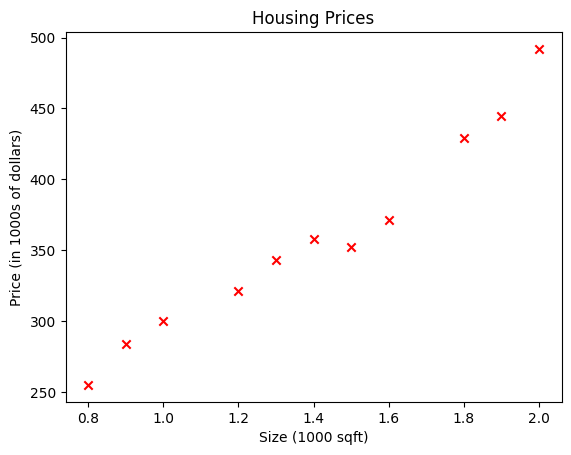

In [6]:
# Plot the data points
plt.scatter(x_train, y_train, marker='x', c='r')
# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Size (1000 sqft)')
plt.show()

## Model function

As described in lecture, the model function for linear regression (which is a function that maps from `x` to `y`) is a straight line:

$$ f_{w,b}(x_{(i)}) = wx_{(i)} + b \tag{1}$$

The parameters of the model are `w` and `b`. We will be changing the parameters until the model fits the data best.

<br/> <br/>




## Task 1 - Code the model function

Code a function that computes the output $\hat y$ for any value of x. You will use this to visualize the model. Later you will use it to make a prediction.

This function will compute the value of $f_{w,b}(x^{(i)})$ for all values of x like this:

for $x^{(0)}$, `f_wb = w * x[0] + b`

for $x^{(1)}$, `f_wb = w * x[1] + b`

...

In [7]:
def compute_model_output(x, w, b):
    """
    Computes the prediction of a linear model
    Args:
      x (ndarray (m,)): Data, m examples in a one-dimensional array
      w,b (scalar)    : model parameters
    Returns
      f_wb (ndarray (m,)): model prediction
    """
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb



In [8]:

#Example for initial values of w and b
w = 0
b = 400

print(f"w: {w}")
print(f"b: {b}")

w: 0
b: 400


[400. 400. 400. 400. 400. 400. 400. 400. 400. 400. 400.]


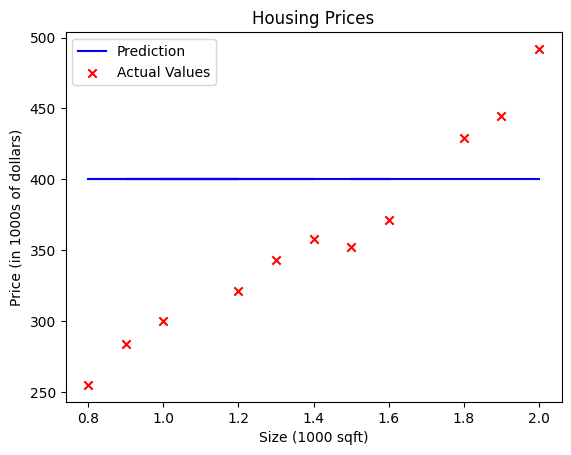

In [14]:
# Compute the model output for all x_train examples
tmp_f_wb = compute_model_output(x_train, w, b,)
print(tmp_f_wb)
bad_y_hat = tmp_f_wb

# Plot your model prediction
plt.plot(x_train, tmp_f_wb, c='b',label='Prediction')

# Plot the data points
plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')

plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()

### Task 2. Cost/loss function
Code a function that inputs the dataset and calculates the mean squared error.

⭕️⭕️

Print the value of the MSE cost function for the poor fit.

⭕️

In [15]:
# Mean Squared Error Cost Function
def cost(y, y_hat):
  assert len(y_hat) == len(y)
  m = len(y)
  return sum((y_hat - y) ** 2) / (2 * m)

def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression
    Args:
      x (ndarray (m,)): Data, m examples in a one-dimensional array
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters
    Returns
      total_cost (scalar): the cost
    """
    assert(len(x) == len(y))
    y_hat = compute_model_output(x, w, b)
    return cost(y_hat, y)

### 3. Better Fit
Play with the values of w and b by hand to find a better fit (by trial and error).
Print the values of w and b that you found to be reasonably good and the corresponding plot. Include the old poor fit line for comparison and add the MSE cost value for both fits in the legend.

⭕️⭕️⭕️⭕️

w: 180
b: 110
J(w,b) = 107.18181818181819


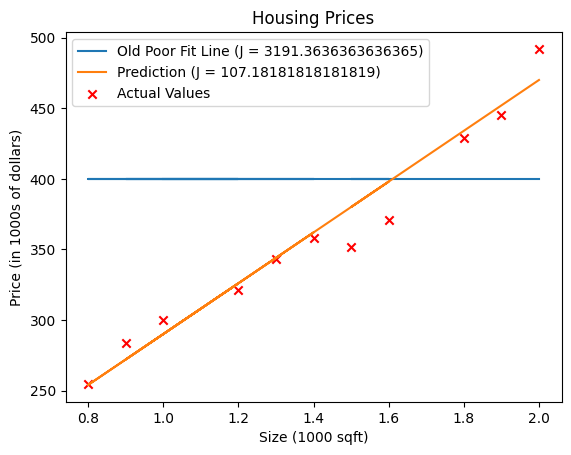

In [ ]:
poor_fit_cost = cost(y_train, bad_y_hat)

def test_w_b(w, b):
  print(f"w: {w}")
  print(f"b: {b}")
  cost = compute_cost(x_train, y_train, w, b)
  print(f"J(w,b) = {cost}")

  # Compute the model output for all x_train examples
  tmp_f_wb = compute_model_output(x_train, w, b,)

  # Plot your model prediction
  plt.plot(x_train, bad_y_hat, label=f'Old Poor Fit Line (J = {poor_fit_cost})')
  plt.plot(x_train, tmp_f_wb, label=f'Prediction (J = {cost})')

  # Plot the data points
  plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')

  plt.title("Housing Prices")
  plt.ylabel('Price (in 1000s of dollars)')
  plt.xlabel('Size (1000 sqft)')
  plt.legend()
  plt.show()
  

# test_w_b(1, 0)
# test_w_b(1, 0)
# test_w_b(2, 0)
# test_w_b(5, 0)
# test_w_b(10, 0)
# test_w_b(20, 0)
# test_w_b(50, 0)
# test_w_b(100, 0)
# test_w_b(200, 0)
# test_w_b(250, 0)
test_w_b(180, 110)
# test_w_b(300, 0)
# test_w_b(250, 100)

### Q1
What is special about the value of the cost function which yields the best fit line?

⭕️⭕️

It takes the difference between the predicted value ($\hat y$) and the actual value ($y$) and then squares it. The squaring ensures that both predictions that are too high and predictions that are too low are punished. It is squared rather than the absolute value in order to punish outliers. Then it takes the average of the costs.

### Task 4. Prediction
Use your model to make a prediction.

A house with 1230 sqft. is going on the market. What price do you predict it will sell at? (use your best fit parameters from Task 3 and print your prediction).

⭕️

In [26]:
w_best = 180
b_best = 110
x = 1.230 # in 1000's of sq ft
prediction = w_best * x + b_best
print(f"The house should sell for around ${prediction * 1000}")


The house should sell for around $331400.0


# Points to remember

 - Linear regression builds a model which establishes a relationship between features and targets
     - For simple linear regression, the model has two parameters *w* and *b* whose values are **fit** using *training data*.
     - once a model's parameters have been set to an optimal value, the model can be used to make predictions on novel data.